In [5]:
pip install seaborn 

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. IMPORT LIBRARIES

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set visualization theme
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

2. LOAD DATASET

In [8]:
DATA_PATH = "data/sales_data.csv"

df = pd.read_csv(DATA_PATH)

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    dayfirst=True
)

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


3. DATASET VALIDATION AND STRUCTURE

In [9]:
print("Dataset shape:",df.shape)
df.info()

Dataset shape: (100, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB


3. MISSING VALUES CHECK

In [10]:
df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

4. FEATURE ENGINEERING

In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,January,1
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,January,2
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,January,3
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,January,4
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,January,5


5. PRICE DISTRIBUTION BY PRODUCT (BOX PLOT)

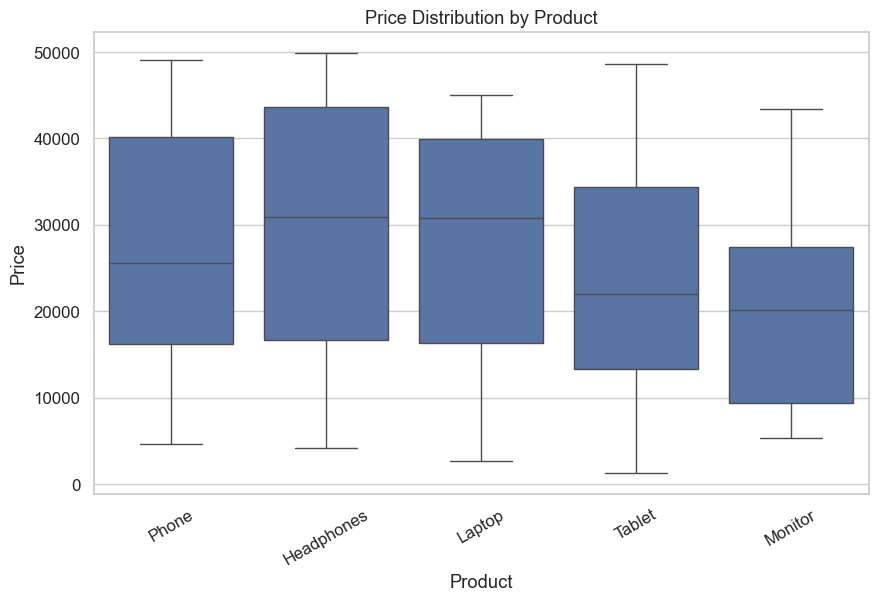

In [12]:
plt.figure()
sns.boxplot(x="Product", y="Price", data=df)
plt.title("Price Distribution by Product")
plt.xticks(rotation=30)
plt.show()

- The box plot reveals variation in pricing across product categories.
- Laptops typically show higher median prices compared to accessories.
- Outliers may represent premium sales.

6. QUANTITY DISTRIBUTION(VIOLIN PLOT)

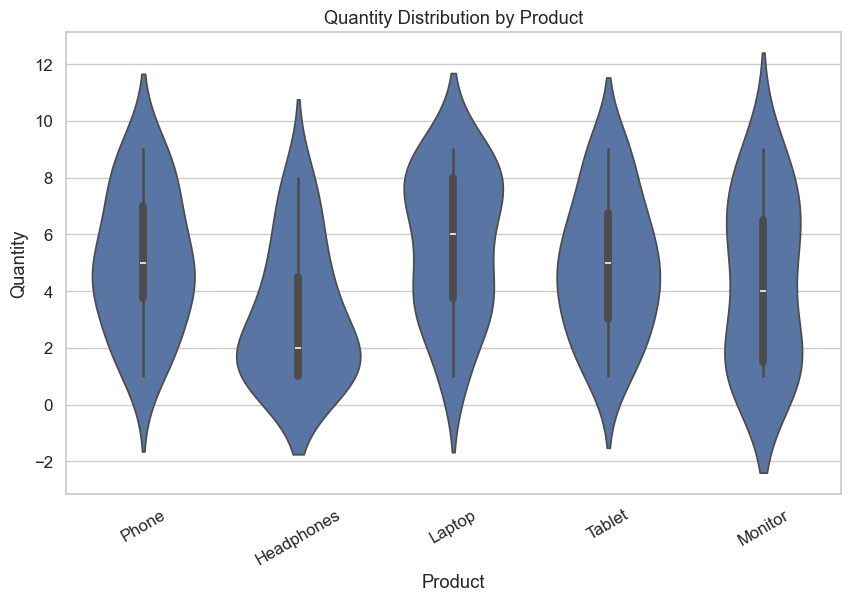

In [13]:
plt.figure()
sns.violinplot(x="Product", y="Quantity", data=df)
plt.title("Quantity Distribution by Product")
plt.xticks(rotation=30)
plt.show()

- The violin plot shows purchase frequency distribution.
- Certain products exhibit more consistent purchase quantities.

7. CORRELATION HEATMAP

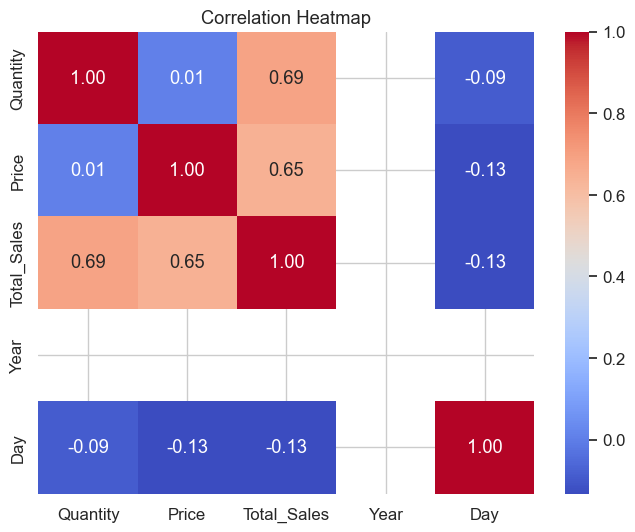

In [14]:
numeric_df = df.select_dtypes(include="number")
correlation = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- Strong positive correlation between Quantity and Total Sales.
- Price influences total revenue significantly.

8. DAILY SALES TREND(PLOTLY INTERACTIVE)

In [15]:
daily_sales = df.groupby("Date")["Total_Sales"].sum().reset_index()

fig = px.line(
    daily_sales,
    x="Date",
    y="Total_Sales",
    title="Daily Sales Trend",
    markers=True,
    template="plotly_white"
)

fig.show()

- Sales fluctuate daily.
- Peaks may indicate promotions or high-demand periods.

9. PRODUCT REVENUE CONTRIBUTION

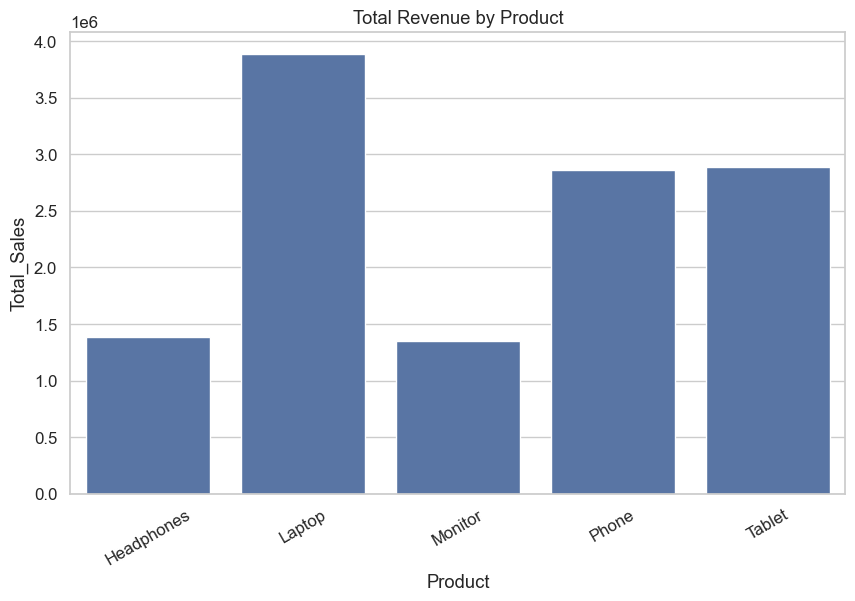

In [16]:
product_sales = df.groupby("Product")["Total_Sales"].sum().reset_index()

plt.figure()
sns.barplot(data=product_sales, x="Product", y="Total_Sales")
plt.title("Total Revenue by Product")
plt.xticks(rotation=30)
plt.show()

- Phones generate highest revenue.
- Accessories contribute smaller but consistent revenue.

10. SALES BY REGION

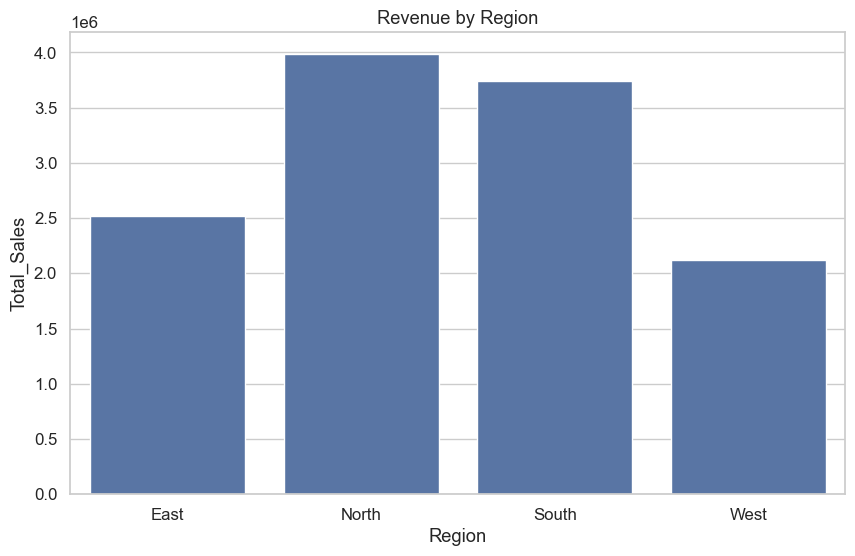

In [17]:
region_sales = df.groupby("Region")["Total_Sales"].sum().reset_index()

plt.figure()
sns.barplot(data=region_sales, x="Region", y="Total_Sales")
plt.title("Revenue by Region")
plt.show()

- North and East regions show strong sales contribution.
- Regional targeting strategies can be derived from this analysis.

11. CUSTOMER SPENDING BEHAVIOUR

In [18]:
customer_sales = (
    df.groupby("Customer_ID")
    .agg({"Total_Sales": "sum", "Quantity": "sum"})
    .reset_index()
)

fig = px.scatter(
    customer_sales,
    x="Quantity",
    y="Total_Sales",
    hover_data=["Customer_ID"],
    title="Customer Segmentation",
    template="plotly_white"
)

fig.show()

- High quantity & high revenue customers represent premium segment.
- Potential for loyalty programs.

12. BUSINESS METRICS

In [19]:
total_revenue = df["Total_Sales"].sum()
total_orders = len(df)
top_product = df.groupby("Product")["Total_Sales"].sum().idxmax()
best_region = df.groupby("Region")["Total_Sales"].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Top Product:", top_product)
print("Best Region:", best_region)

Total Revenue: 12365048
Total Orders: 100
Top Product: Laptop
Best Region: North
